Uncalibrated Brier: 0.2652760677523286
Uncalibrated ROC AUC: 0.6826253211127259
Calibrated Brier: 0.17427749450416663
Calibrated ROC AUC: 0.6879883729037172


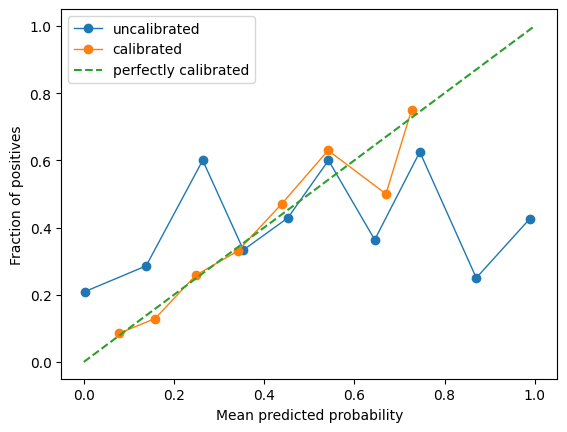

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score

df_train = pd.read_csv("../train_V2_cleaned.csv")
df_train = df_train.drop(columns=["outcome_damage_amount", "outcome_profit"])

X = df_train.drop(columns="outcome_damage_inc")
y = df_train["outcome_damage_inc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.8, random_state=42)),
    ("under", RandomUnderSampler(random_state=67)),
    ("gbc", GradientBoostingClassifier(
        loss="exponential",
        learning_rate=0.25,
        n_estimators=484,
        subsample=0.51,
        criterion="friedman_mse",
        min_samples_split=4,
        min_samples_leaf=3,
        max_depth=12,
        tol=0.0449,
        random_state=42
    ))
])

# Before Calibrate
base_pipeline.fit(X_train, y_train)
y_prob_uncal = base_pipeline.predict_proba(X_test)[:, 1]

print("Uncalibrated Brier:", brier_score_loss(y_test, y_prob_uncal))
print("Uncalibrated ROC AUC:", roc_auc_score(y_test, y_prob_uncal))

calibrated_model = CalibratedClassifierCV(
    estimator=base_pipeline,
    cv=5,
    method="isotonic",
    n_jobs=-1
)

# Calibrate
calibrated_model.fit(X_train, y_train)
y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]

print("Calibrated Brier:", brier_score_loss(y_test, y_prob_cal))
print("Calibrated ROC AUC:", roc_auc_score(y_test, y_prob_cal))

# Plot
fop_uncal, mpv_uncal = calibration_curve(y_test, y_prob_uncal, n_bins=10)
fop_cal, mpv_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)

plt.plot(mpv_uncal, fop_uncal, marker="o", linewidth=1, label="uncalibrated")
plt.plot(mpv_cal, fop_cal, marker="o", linewidth=1, label="calibrated")
plt.plot([0, 1], [0, 1], linestyle="--", label="perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.show()

# Train on all data

In [2]:
df_train = pd.read_csv("../train_V2_cleaned.csv")
df_score = pd.read_csv("../score_cleaned.csv")

df_train = df_train.drop(columns=["outcome_damage_amount", "outcome_profit"])

X_full = df_train.drop(columns="outcome_damage_inc")
y_full = df_train["outcome_damage_inc"]

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.8, random_state=42)),
    ("under", RandomUnderSampler(random_state=67)),
    ("gbc", GradientBoostingClassifier(
        loss="exponential",
        learning_rate=0.25,
        n_estimators=484,
        subsample=0.51,
        criterion="friedman_mse",
        min_samples_split=4,
        min_samples_leaf=3,
        max_depth=12,
        tol=0.0449,
        random_state=42
    ))
])

final_calibrated_model = CalibratedClassifierCV(
    estimator=final_pipeline,
    cv=5,
    method="isotonic",
    n_jobs=-1
)

final_calibrated_model.fit(X_full, y_full)

y_pred = final_calibrated_model.predict(df_score)
y_prob = final_calibrated_model.predict_proba(df_score)[:, 1]

df_score["outcome_damage_inc"] = y_pred
df_score["outcome_damage_inc_proba"] = y_prob
df_score.to_csv("../score_cleaned.csv", index=False)

In [3]:
df_score_test = pd.read_csv("../score_cleaned.csv")
df_score_test.head()

,income_am,profit_last_am,profit_am,damage_am,damage_inc,crd_lim_rec,credit_use_ic,gluten_ic,lactose_ic,insurance_ic,...,score2_pos_missing,score2_neg_missing,score3_pos_missing,score3_neg_missing,score4_pos_missing,score4_neg_missing,score5_pos_missing,score5_neg_missing,outcome_damage_inc,outcome_damage_inc_proba
0,5660.0,4320.0,8640.0,0.0,0.0,8000.0,0.0,0.0,1.0,0.0,...,0,0,1,1,1,1,1,1,0.0,0.454947
1,3990.0,9.0,3450.0,0.0,0.0,12500.0,0.0,0.0,0.0,1.0,...,1,1,1,1,1,1,1,1,0.0,0.226547
2,1158.0,82.0,4194.0,408.0,4.0,12000.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,0,1,1,0.0,0.338842
3,2451.0,791.0,2119.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,1,1,1,1,1,1,0.0,0.224548
4,946.0,222.0,2036.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1,1,1,1,1,1,1,1,0.0,0.150515
